# IEEE-14 smart grid recovery model with time-dependent transitions
Sanfan Liu, Nov 2025

Import libraries

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')  #access to your Google drive
#enter your Google drive folder"simulator"
%cd drive/My\ Drive/simulator
import pandas as pd

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
[Errno 2] No such file or directory: 'drive/My Drive/simulator'
/content/drive/My Drive/simulator


# Import datasets

D matrix for IEEE-14, in order of Line 1-20, PMU 1-3, FACTS 1-3, DS

In [ ]:
# @title
# copied from Koosha's output
D = np.array([[
0,0.8289319249,0.00176056338,0,0,0,0.03139671362,0,0,0.01203051643,0.003227699531,0,0.003521126761,0,0.005868544601,0.02846244131,0,0.004107981221,0,0.0005868544601,0,0,0,0,0,0.07834507042,0
],[0.01598915989,0,0.02520325203,0.00135501355,0.0027100271,0.00298102981,0.0647696477,0.00460704607,0,0.006775067751,0.007046070461,0.00135501355,0.01246612466,0,0.02384823848,0.04742547425,0.00162601626,0.01138211382,0.0008130081301,0.00460704607,0.5601626016,0,0,0,0,0.1967479675,0
],[0,0,0,0.02561366062,0,0.005336179296,0.1270010672,0,0,0,0.007470651014,0,0,0,0.01921024546,0.003201707577,0,0,0,0,0,0.8100320171,0,0,0,0.03628601921,0
],[0,0.001225490196,0.01225490196,0,0,0,0.001225490196,0.007352941176,0,0.02573529412,0,0,0.00612745098,0,0.07230392157,0,0.001225490196,0.02083333333,0.001225490196,0.001225490196,0,0,0.7659313725,0,0,0.06862745098,0
],[0,0,0,0,0,0,0.001398601399,0.001398601399,0,0,0,0,0,0,0,0.001398601399,0,0,0,0,0,0,0,0,0,0,0
],[0,0,0,0.02341597796,0,0,0.001377410468,0.001377410468,0,0.001377410468,0,0,0,0,0,0,0,0.04545454545,0,0,0,0,0,0,0,0.001377410468,0
],[0.1013460016,0,0.06254948535,0.08630245447,0.005542359462,0.01979414093,0,0.003167062549,0.002375296912,0.04117181314,0.01821060966,0.0007917656374,0.005542359462,0,0.01029295329,0.0126682502,0.003167062549,0.009501187648,0,0.02296120348,0,0,0,0,0,0.05621536025,0
],[0.002805049088,0,0,0.001402524544,0,0,0.002805049088,0,0.005610098177,0.002805049088,0,0,0,0,0.001402524544,0.008415147265,0,0,0,0,0,0,0,0,0,0.004207573633,0
],[0,0,0,0,0,0,0.003081664099,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
],[0,0,0.01326899879,0,0,0,0.04342581423,0.003618817853,0,0,0.00482509047,0,0,0,0.02412545235,0.01085645356,0.001206272618,0.003618817853,0,0,0,0,0,0,0,0.00482509047,0
],[0,0,0,0.001375515818,0,0,0.001375515818,0,0,0.005502063274,0,0.005502063274,0,0,0.005502063274,0.001375515818,0,0,0,0,0,0,0,0,0,0,0
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006153846154,0,0,0.001538461538,0,0,0,0,0,0,0
],[0,0,0.008298755187,0.001383125864,0,0,0.006915629322,0,0,0,0.001383125864,0,0,0,0,0.005532503458,0,0,0.008298755187,0,0,0,0,0,0,0,0
],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
],[0,0,0.0009940357853,0.005964214712,0.004970178926,0.03280318091,0.002982107356,0,0,0.0009940357853,0.0009940357853,0,0.01292246521,0,0,0.1153081511,0.03180914513,0,0,0,0,0,0,0,0,0.02087475149,0
],[0,0,0.008865248227,0,0.007978723404,0.001773049645,0.01507092199,0.007978723404,0,0.0008865248227,0.0008865248227,0,0,0,0.03014184397,0,0.00975177305,0,0,0.1019503546,0,0,0,0,0,0.01329787234,0
],[0,0,0.001426533524,0.005706134094,0,0.004279600571,0.007132667618,0,0,0,0.001426533524,0,0,0,0,0,0,0,0,0.007132667618,0,0,0,0,0,0,0
],[0,0,0.001303780965,0,0,0,0.001303780965,0.04172099087,0,0,0,0,0,0,0.00260756193,0.001303780965,0.001303780965,0,0,0.007822685789,0,0,0,0,0,0,0
],[0,0,0,0,0,0.001538461538,0,0,0,0,0,0,0,0,0,0.006153846154,0,0,0,0,0,0,0,0,0,0,0
],[0,0,0,0,0,0,0.001191895113,0,0,0.004767580453,0.001191895113,0,0,0,0.001191895113,0,0,0,0,0,0,0,0,0,0,0.001191895113,0
],[0.3883106485,0,0.004003202562,0,0,0,0.0005337603416,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.001601281025,0
],[0.006970069701,0.0102501025,0,0.0020500205,0,0,0,0,0,0.009840098401,0.0004100041,0,0,0,0.0004100041,0.0004100041,0,0,0,0.0016400164,0,0,0,0,0,0.0032800328,0
],[0.0008676789588,0.007809110629,0,0,0,0.0004338394794,0.0004338394794,0,0,0.003470715835,0,0,0,0,0.0004338394794,0,0,0.0004338394794,0,0,0,0,0,0,0,0.005206073753,0
],[0.3166666667,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
],[0.02380952381,0.007738095238,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
],[0.04578313253,0,0.02203098107,0.001032702238,0.01514629948,0.001721170396,0.02719449225,0.0006884681583,0.0006884681583,0.001721170396,0.003786574871,0,0.001376936317,0,0.03580034423,0.01858864028,0.0003442340792,0.001721170396,0,0.006540447504,0,0,0,0,0,0,0
],[0.119047619,0.05,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
]])

In [ ]:
D = D**(1/2.5)#amplify D

Calculate serivce capacity value for each state

In [ ]:
# @title
# prompt: read numbers from "csi.txt", created by Gemini
def read_numbers_from_file(filename):
    """Reads numbers from a file and returns them as a list."""

    numbers = []
    try:
        with open(filename, 'r') as file:
            for line in file:
                # Attempt to convert each line to a float, skipping lines that don't contain numbers
                try:
                  # Handle potential cases where there might be more than one number or non numeric characters on a line
                  for word in line.split():
                    num = float(word) # will throw an exception if word is not a valid number.
                    numbers.append(num)
                except ValueError:
                    pass # Skip lines that do not contain valid numbers
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
        return None

    return numbers

# Example usage (replace with the actual path to your file)
sci_values = read_numbers_from_file("csi.txt")


In [ ]:
# @title
#locate the CSI in the file
def reward_calculation(X_t):
  tempX = np.zeros(N)
  location = 0

  for i in range(0, N):   #swap 1 and 0s, because MATLAB was coded differently
    if X_t[i] != 0:
      tempX[i] = 1
    else:
      tempX[i] = 0
  for i in range(0, N):   #reverse 1 and 0s
    tempX[i] = 1-tempX[i]
  if tempX[26] == 0:    #check if DS is failed
    tempX[25] = 0
    tempX[24] = 0
    tempX[23] = 0
  for i in range(0, 20):  #calculate location for lines
    location = location + 2**((i+3) * tempX[i])

  for i in range(23, 26): # calculate location for FACTS
    location = location + 2**((i-23) * tempX[i])
  return sci_values[int(location)]

# Functions for simulation

find the failing component in next state

In [ ]:
# @title
#function to find the failed components in the next state
#x_t, comopnent system state
#t, current time step
def Next_state(X_t, t, failure_counter):
  fail_propagation = np.zeros(N)
  for i in range(0, N):
    if X_t[i] != 0:
      # Calculate element-wise power for D, as (t-X_t[i]) can be a float.
      # The original line 'D_temp = matrix_power(input_array, 0)D**(t-X_t[i])' was syntactically incorrect.
      D_temp = D**(t-X_t[i]+1)
      fail_propagation = fail_propagation + D_temp[i]
  for i in range(0, N):
    RV = random.uniform(0,1)
    if fail_propagation[i] > RV:
      if X_t[i] == 0:
        failure_counter = failure_counter + 1
      X_t[i] = t
  return (X_t, failure_counter)

check if repair assignment is needed, satified condition of (failed component not under repair) & (there is crew idling)

In [ ]:
# @title
#function to schedule the crew to work on failed components
# note that component index doesnt prefect align with crew's state because crew has to have one extra state for idle
# so for N components, crews has N+1 state and the idling state will always be the (N)th state
# dictionary for all variables used:
#X_t, component-level system state, X_t[i] has 2 states, 0 & 1, 0 operational, 1 failed
#Y_t, crew state, Y_t[i] = the current repair task of crew i (the component crew i is fixing)
#z_t, amount of time left for crew to finish working on the current task
#repair_counter, count the total number of tasks assigned
def repair_condition(X_t, Y_t, z_t , repair_counter):
  z_t = z_t - 1
  for i in range(0, M):
    if z_t[i] <= 0:             #find finished repairs
      if Y_t[i]<N:
        X_t[int(Y_t[i])] = 0                     #component got repaired set to operational
      Y_t[i] = N                       #crew set to be idle
  #collect failed components
  fail_list = []
  for i in range(0, N):
    if X_t[i] != 0:               #find failed component
      fail_list.append(i)           #append the failed component into failure list
      for j in range(0, M):
        if i == Y_t[j]:         #if crew is already working on fixing this comonent
          fail_list.pop()     #remove the component from the list
  if fail_list == []:         #end repair scheduling algorithm if nothing to assign
    return (X_t, Y_t, z_t, repair_counter)

  (fail_list, Y_t, z_t, repair_counter) = assign_repair(fail_list, Y_t, z_t, repair_counter)
  return (X_t, Y_t, z_t, repair_counter)

assign repair task to crews

In [ ]:
# @title
def sort_fail_list_by_pre_list(pre_list, fail_list):
  """
  Sorts fail_list according to the order of elements in pre_list.

  Args:
    pre_list: A list containing numbers from 0 to 27 in a specific order.
    fail_list: A list containing a subset of numbers from 0 to 27.

  Returns:
    A new list with elements from fail_list sorted according to pre_list.
  """
  # Convert fail_list to a set for efficient lookup
  fail_set = set(fail_list)
  sorted_fail_list = []

  for item in pre_list:
    if item in fail_set:
      sorted_fail_list.append(item)
      # Optional: if you want to remove elements from fail_set as they are found
      # This would be useful if fail_list can have duplicates that should all be included
      # fail_set.remove(item)
  return sorted_fail_list

# Example Usage:
# pre_list_example = [5, 1, 8, 3, 2, 0, 7, 6, 4, 9]
# fail_list_example = [3, 7, 1, 9]
# sorted_list = sort_fail_list_by_pre_list(pre_list_example, fail_list_example)
# print(sorted_list) # Output: [1, 3, 7, 9]

In [ ]:
# @title
#function to assign repair tasks to idling crews
#fail_list, list of all failed, not under repair, components
#y_t, crew state
#repair_counter, count the number of tasks assigned

def assign_repair(fail_list, Y_t, z_t, repair_counter):
  for i in range(0, 19):      # setup repair time for Lines
      repair_time[i] = inverse_lognormal_cdf(np.random.rand(), mu=1, sigma=0.15)     #hours
  for i in range(19, N-1):      # setup repair time for smart devices
      repair_time[i] = (inverse_exponential_cdf(np.random.rand(), 0.1)+1)/60   #hours
  #extend repair time for area under weather, line 1, 3, 4, 5, 6, pmu1, FACTS 1 and 3.
  global Massive
  if Massive:  #turn on/off by switch between True/False
    for i in [0, 2, 3, 4, 5, 20, 23, 25]:
      repair_time[i] = repair_time[i]+1
  global algorithm  #0-randomized, 1-pre-computed list, 2-look-ahead, 3-dynamic dependency
  for i in range(0, M):
    if Y_t[i] == N:   #check for idling crews
      if not fail_list:  # Check if fail_list is empty
        return (fail_list, Y_t, z_t, repair_counter) # Return immediately if empty
      repair_counter = repair_counter + 1
      match algorithm:
        case 0: #randomized method
          random.shuffle(fail_list)     # shuffle fail_list
          Y_t[i] = fail_list[0]         # assign the first component to idling crew
          z_t[i] = repair_time[fail_list[0]] #assign repair time to coresponding tracker
          fail_list.pop(0)              #remove component from the fail list
        case 1: #pre_computed list
          global pre_list               #fetch pre-computed list
          sorted_list = sort_fail_list_by_pre_list(pre_list, fail_list)
          Y_t[i] = sorted_list[0]         # assign the first component to idling crew
          z_t[i] = repair_time[sorted_list[0]] #assign repair time to coresponding tracker
          fail_list.remove(sorted_list[0])              #remove component from the fail list
        case 2: #look ahead
          best_component = fail_list[0] #fetch first component on the list
          if len(fail_list) > 1:      #if only 1 component, then skip comparision
            X_u = np.copy(X_t)
            X_u[best_component] = 0   #assume first component is repair
            best_reward = (reward_calculation(X_t) - reward_calculation(X_u)/repair_time[best_component]) #find the performance when its repaired
            for j in range(1, len(fail_list)):    #for the rest of components on the list
              X_v =  np.copy(X_t)
              X_v[fail_list[j]] = 0   #assume jth component is fixed
              temp_reward = (reward_calculation(X_t) - reward_calculation(X_v)/repair_time[fail_list[j]]) #find its reward after its fixed
              if temp_reward > best_reward:      #compare the performance gap
                best_reward = temp_reward        #keep the better performance
                best_component = fail_list[j]     # keep the better component
          Y_t[i] = best_component   #assign the best component to repair crew
          z_t[i] = repair_time[best_component] #assign repair time
          fail_list.remove(best_component) #remove from the list
        case 3: #dynamic dependency
          best_component = fail_list[0] # fetch first component from the list
          if len(fail_list) > 1:        #if there is more than one failed component
            highest_effect=0
            for k in range(0, N):
              if X_t[k] == 0:
                highest_effect = highest_effect + D[best_component][k]
            highest_effect = highest_effect / repair_time[best_component] #find the dependency effect caused by best_component
            for j in range(1, len(fail_list)):  #compare with other components
              temp_effect = 0
              for k in range(0, N):
                if X_t[k] == 0:
                  temp_effect = temp_effect + D[fail_list[j]][k]    #find the dependency effect caused by fail_list[j]
              temp_effect = temp_effect / repair_time[fail_list[j]]  #find the dependency effect caused by testing component
              if temp_effect > highest_effect:
                highest_effect = temp_effect
                best_component = fail_list[j]
          Y_t[i] = best_component   #assign the best component to repair crew
          z_t[i] = repair_time[best_component] #assign repair time
          fail_list.remove(best_component) #remove from the list
        case _: #handle invalid algorithms
          print("invalid algorithm")
          sys.exit()

  return (fail_list, Y_t, z_t, repair_counter)

Math functions, inverse weibull, exponential, lognormal cdf

In [ ]:
# @title
def inverse_weibull_cdf(p, lambda_val, k_val): #written by Gemini, double checked by Sanfan
    """Inverse of the cumulative distribution function (CDF) for a Weibull distribution.
    Args:
        p (float): The probability (0 <= p < 1).
        lambda_val (float): The scale parameter (lambda) of the Weibull distribution.
        k_val (float): The shape parameter (k) of the Weibull distribution. which is the indicator of the distribution, k> 1 means success rate increase, k<1 means failure rate decrease.
    Returns:
        float: The value x such that F(x) = p.
    """
    if not (0 <= p < 1):
        raise ValueError("Probability 'p' must be between 0 and 1 (exclusive of 1).")

    # Inverse CDF formula: x = lambda * (-ln(1 - F(x)))^(1/k)
    x = lambda_val * ((-np.log(1 - p)))**(1/k_val)
    return x


In [ ]:
# @title
import numpy as np

def inverse_exponential_cdf(p, lambda_val):
    """Inverse of the cumulative distribution function (CDF) for an Exponential distribution.

    Args:
        p (float): The probability (0 <= p < 1).
        lambda_val (float): The rate parameter (lambda) of the Exponential distribution.

    Returns:
        float: The value x such that F(x) = p.
    """
    if not (0 <= p < 1):
        raise ValueError("Probability 'p' must be between 0 and 1 (exclusive of 1).")
    if lambda_val <= 0:
        raise ValueError("Lambda (rate parameter) must be greater than 0.")

    # Inverse CDF formula: x = - (1/lambda) * ln(1 - p)
    x = - (1 / lambda_val) * np.log(1 - p)
    return x

# Example usage:
# probability = 0.5
# rate_parameter = 0.1 # This means an average of 10 events per unit time
# value_at_p = inverse_exponential_cdf(probability, rate_parameter)
# print(f"For p={probability} and lambda={rate_parameter}, x = {value_at_p}")


In [ ]:
# @title
import numpy as np
from scipy.stats import norm

def inverse_lognormal_cdf(p, mu, sigma):
    """Inverse of the cumulative distribution function (CDF) for a Lognormal distribution.

    Args:
        p (float): The probability (0 < p < 1).
        mu (float): The mean of the logarithm of the random variable.
        sigma (float): The standard deviation of the logarithm of the random variable.

    Returns:
        float: The value x such that F(x) = p.
    """
    if not (0 < p < 1):
        raise ValueError("Probability 'p' must be between 0 and 1 (exclusive).")
    if sigma <= 0:
        raise ValueError("Standard deviation 'sigma' must be greater than 0.")

    # The inverse lognormal CDF is exp(mu + sigma * Z), where Z is the
    # inverse standard normal CDF (ppf) of p.
    x = np.exp(mu + sigma * norm.ppf(p))
    return x

# Example usage:
# probability = 0.5
# mu_param = 0.0
# sigma_param = 0.5
# value_at_p = inverse_lognormal_cdf(probability, mu_param, sigma_param)
# print(f"For p={probability}, mu={mu_param}, sigma={sigma_param}, x = {value_at_p}")

# Inputs for simulation


In [ ]:
#location 0~19 lines, 20~22 PMUs, 23~25 FACTS, 26 DS
Massive = False              #set for extreme weather with massive failure case
N = 27                      #number of components
M = 5                       #number of crews
Max_sim_time = 50          #max simulation time in hours
sim_trials = 1000           #number of trials we are going to run
#choose repair algorithm
algorithm = 0             #0-randomized, 1-pre-computed, 2-Max_capacity, 3-Min_cascade
pre_list = np.array([2, 0, 1, 3, 6, 20, 23, 14, 15, 25, 26,  9,  5, 17, 21, 12, 24,  7, 16, 10, 22, 19, 18, 11, 4,  8, 13])     # reversed prority for pre-computed list
#pre_list = np.array([13,  8,  4, 11, 18, 19, 22, 10, 16,  7, 24, 12, 21, 17,  5,  9, 26, 25, 15, 14, 23, 20,  6,  3,  1,  0,  2])
repair_time = np.zeros(N)
random.seed(0)

# Run Simulation

single faliure cases:

In [ ]:
# @title
result = np.zeros( Max_sim_time)
repair_attemp_record = np.zeros(200)
average_Performance = np.zeros(Max_sim_time)
total_repair_attemp = 0
total_additional_failure = 0
success_rate = sim_trials*N
deadline_counter = N*sim_trials
for failure in range(0, N):
  failure_case = np.zeros(N)
  failure_case[failure] = 1
  for trial in range(0, sim_trials+1):
    random.seed(trial)
    np.random.seed(trial)
    systemPerformance =  np.ones(Max_sim_time)
    repair_counter = 0  #count the number of tasks assigned
    failure_counter = 0 #count the number of failed components
    X_t = np.zeros(N)
    Y_t = np.zeros(M)     #crew state at current time
    for i in range(0, M):
      Y_t[i] = N
    z_t = np.zeros(M)   # repair time tracker
    t=1   #current time
    X_t = np.copy(failure_case)
    while((t < Max_sim_time-1) and (X_t.sum() != 0) ):
      #randomize repair time
      (X_t, Y_t,  z_t, repair_counter) = repair_condition(X_t, Y_t, z_t, repair_counter)
      (X_t, failure_counter) = Next_state(X_t, t, failure_counter)
      t = t + 1
      systemPerformance[t] = reward_calculation(X_t)# work on finding system performance
      if t == 13:
        if systemPerformance[t] < 0.9:
          deadline_counter = deadline_counter - 1  #for counting the recovery deadline %

      if t > Max_sim_time-2:
        success_rate = success_rate - 1   #success rate is Coverage

    result[t] = result [t] +1
    total_repair_attemp = total_repair_attemp + repair_counter;
    total_additional_failure = total_additional_failure + failure_counter
    average_Performance = average_Performance + systemPerformance
  print(failure)

average_Performance = (average_Performance / (N*sim_trials) )
average_success_rate = success_rate / (N*sim_trials)
total_repair_attemp = (total_repair_attemp/(N*sim_trials) -1)
total_additional_failure = (total_additional_failure/(N*sim_trials) )
repair_duration = 0         #find average repair time in hours
for i in range(0, Max_sim_time):
  repair_duration = repair_duration + result[i] * i
repair_duration = (repair_duration / sim_trials / N)
deadline_counter = deadline_counter / (N*sim_trials)

Cyber attack case

In [ ]:
# @title
result = np.zeros( Max_sim_time)
repair_attemp_record = np.zeros(200)
average_Performance = np.zeros(Max_sim_time)
total_repair_attemp = 0
total_additional_failure = 0
success_rate = sim_trials
deadline_counter = sim_trials
for failure in range(0, 1):
  failure_case = np.zeros(N)
  #initial failure for 3 comopnents with highest sum of direct influence
  failure_case[22] = 1  #PMU3, on bus 9
  failure_case[24] = 1  #FACTS2, on line between bus 1 and 5
  failure_case[21] = 1  #PMU2, on bus 6
  for trial in range(0, sim_trials+1):
    random.seed(trial)
    np.random.seed(trial)
    systemPerformance =  np.ones(Max_sim_time)
    repair_counter = 0  #count the number of tasks assigned
    failure_counter = 0 #count the number of failed components
    X_t = np.zeros(N)
    Y_t = np.zeros(M)     #crew state at current time
    for i in range(0, M):
      Y_t[i] = N
    z_t = np.zeros(M)   # repair time tracker
    t=1   #current time
    X_t = np.copy(failure_case)
    while((t < Max_sim_time-1) and (X_t.sum() != 0) ):
      #randomize repair time
      (X_t, Y_t,  z_t, repair_counter) = repair_condition(X_t, Y_t, z_t, repair_counter)
      (X_t, failure_counter) = Next_state(X_t, t, failure_counter)
      t = t + 1
      systemPerformance[t] = reward_calculation(X_t)# work on finding system performance
      if t == 13:
        if systemPerformance[t] < 0.9:
          deadline_counter = deadline_counter - 1
      if t > Max_sim_time-2:
        success_rate = success_rate - 1

    result[t] = result [t] +1
    total_repair_attemp = total_repair_attemp + repair_counter;
    total_additional_failure = total_additional_failure + failure_counter
    average_Performance = average_Performance + systemPerformance
  print(failure)

average_Performance = (average_Performance / (sim_trials) )
average_success_rate = success_rate / (sim_trials)
total_repair_attemp = (total_repair_attemp/(sim_trials) -1)
total_additional_failure = (total_additional_failure/(sim_trials) )
repair_duration = 0         #find average repair time in hours
for i in range(0, Max_sim_time):
  repair_duration = repair_duration + result[i] * i
repair_duration = (repair_duration / sim_trials)
deadline_counter = deadline_counter / (sim_trials)

0


Massive failure

In [ ]:
# @title
result = np.zeros( Max_sim_time)
repair_attemp_record = np.zeros(200)
average_Performance = np.zeros(Max_sim_time)
total_repair_attemp = 0
total_additional_failure = 0
success_rate = sim_trials
deadline_counter = sim_trials
for failure in range(0, 1):
  failure_case = np.zeros(N)
  #initial failure with all lines down
  failure_case[0] = 1   #line 1 fails at t=1
  failure_case[4] = 1   #line 5 fails at t=1
  for trial in range(0, sim_trials+1):
    random.seed(trial)
    np.random.seed(trial)
    systemPerformance =  np.ones(Max_sim_time)
    repair_counter = 0  #count the number of tasks assigned
    failure_counter = 0 #count the number of failed components
    X_t = np.zeros(N)
    Y_t = np.zeros(M)     #crew state at current time
    for i in range(0, M):
      Y_t[i] = N
    z_t = np.zeros(M)   # repair time tracker
    t=1   #current time
    X_t = np.copy(failure_case)
    while((t < Max_sim_time-1) and (X_t.sum() != 0) ):
      #failue after inital state
      if t == 2:
        X_t[3] = 2   #line 4 fails at t=2
      if t == 3:
        X_t[2] = 3   #line 3 fails at t=3
      if t == 5:
        X_t[5] = 5   #line 6 fails at t=5
      #randomize repair time
      (X_t, Y_t,  z_t, repair_counter) = repair_condition(X_t, Y_t, z_t, repair_counter)
      (X_t, failure_counter) = Next_state(X_t, t, failure_counter)
      t = t + 1
      systemPerformance[t] = reward_calculation(X_t)# work on finding system performance
      if t == 15:
        if systemPerformance[t] < 0.9:
          deadline_counter = deadline_counter - 1
      if t > Max_sim_time-2:
        success_rate = success_rate - 1

    result[t] = result [t] +1
    total_repair_attemp = total_repair_attemp + repair_counter;
    total_additional_failure = total_additional_failure + failure_counter
    average_Performance = average_Performance + systemPerformance
  print(failure)

average_Performance = (average_Performance / (sim_trials) )
average_success_rate = success_rate / (sim_trials)
total_repair_attemp = (total_repair_attemp/(sim_trials) -5)
total_additional_failure = (total_additional_failure/(sim_trials) -3)
repair_duration = 0         #find average repair time in hours
for i in range(0, Max_sim_time):
  repair_duration = repair_duration + result[i] * i
repair_duration = (repair_duration / sim_trials)
deadline_counter = deadline_counter / (sim_trials)

0


# Result organizing functions

In [ ]:
print(total_additional_failure)  #find number of additional failures

11.64


In [ ]:
print(repair_duration)  #avg. earliest restoration time

12.039


In [ ]:
print(deadline_counter) #Recovery restoiration time

0.836


In [ ]:
print(average_success_rate) #Coverage

0.997


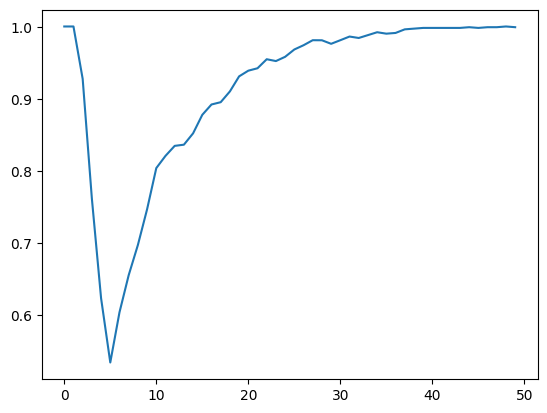

In [ ]:
plt.plot(average_Performance) #Figures for surivivuability vs. time since disruption
plt.show()

In [ ]:
df = pd.DataFrame(average_Performance)
df.to_csv("averagePerformance.csv")

# unit test functions

In [ ]:
print(total_repair_attemp)  #find number of repair tasks assigned

13.642


for running a single trial in case L1 fails

In [ ]:
# @title
result = np.zeros( Max_sim_time)
repair_attemp_record = np.zeros(200)
average_Performance = np.zeros(Max_sim_time)
total_repair_attemp = 0
for failure in range(0, 2):
  failure_case = np.ones(N)
  failure_case[failure] = 1
  print(failure)
  for trial in range(0, 1):
    random.seed(trial)
    np.random.seed(trial)
    systemPerformance =  np.ones(Max_sim_time)
    repair_counter = 0
    failure_counter = 0

    X_t = np.zeros(N)    #smart grid state at current time
    Y_t = np.zeros(M)     #crew state at current time
    for i in range(0, M):
      Y_t[i] = N
    repair_tracker = np.zeros(M)   # repair time tracker
    t=1   #current time
    begin = False
    X_t = np.copy(failure_case)    #smart grid state at current time
    while((t < Max_sim_time-1) and ( (X_t.sum()) != 0) ) :
      print(X_t,',', Y_t,',', repair_tracker,',', repair_counter,',', systemPerformance[t],',', failure_counter)
      (X_t, Y_t,  repair_tracker, repair_counter) = repair_condition(X_t, Y_t, repair_tracker, repair_counter)
      (X_t, failure_counter) = Next_state(X_t, t, failure_counter)
      t = t + 1
      systemPerformance[t] = reward_calculation(X_t)# work on finding system performance
    total_repair_attemp = total_repair_attemp + repair_counter;
    average_Performance = average_Performance + systemPerformance
if t < Max_sim_time-2:
      print("success")

0
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1.] , [27. 27. 27. 27. 27.] , [0. 0. 0. 0. 0.] , 0 , 1.0 , 0
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1.] , [ 3.  0. 24. 19.  4.] , [2.76464318 2.76876019 0.03764574 0.35671905 2.6408931 ] , 5 , 0.0 , 0
[2. 2. 1. 1. 1. 1. 2. 1. 1. 1. 1. 1. 1. 1. 2. 1. 1. 1. 1. 0. 1. 1. 2. 1.
 0. 2. 1.] , [ 3.  0. 10. 11.  4.] , [1.76464318 1.76876019 2.83691675 2.84230609 1.6408931 ] , 7 , 0.0 , 0
[3. 3. 3. 1. 1. 1. 2. 1. 1. 1. 1. 1. 1. 1. 3. 1. 1. 1. 1. 0. 3. 3. 3. 1.
 0. 2. 1.] , [ 3.  0. 10. 11.  4.] , [0.76464318 0.76876019 1.83691675 1.84230609 0.6408931 ] , 7 , 0.0 , 0
[4. 3. 3. 0. 0. 4. 4. 1. 1. 1. 1. 1. 4. 1. 3. 4. 1. 1. 1. 0. 4. 4. 3. 1.
 0. 4. 1.] , [ 2.  5. 10. 11. 12.] , [2.53197113 2.93125448 0.83691675 0.84230609 2.53259473] , 10 , 0.0 , 1
[5. 5. 3. 0. 0. 4. 4. 1. 1. 1. 0. 0. 4. 1. 3. 4. 1. 1. 1. 5. 5. 5. 3. 1.
 0. 5. 1.] , [ 2.  5.  8. 14. 12.] , [1.53197113 1.93125448

In [ ]:
float (inverse_weibull_cdf(0.9,3,5)) # check weibull return values

3.544576815126535

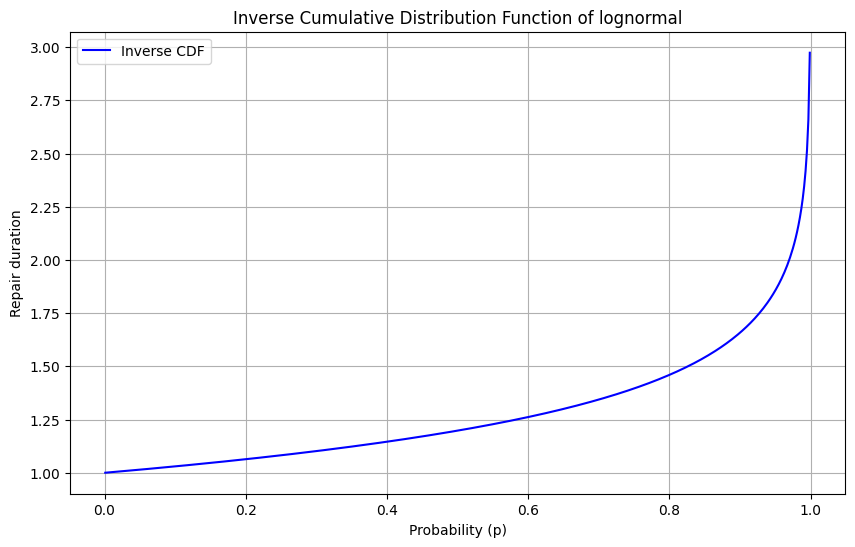

In [ ]:
##check inverse CDF function outputs, created by Gemini
import numpy as np
import matplotlib.pyplot as plt

# Define the current lambda and k values for the plot
current_lambda_val = 3.5
current_k_val = 7

# Generate a range of probabilities from 0 to almost 1
p_values = np.linspace(0.001, 0.999, 500) # Avoid 0 and 1 as log(0) and log(1-1) are undefined

# Calculate the corresponding x values using the inverse_weibull_cdf function
#exponential:
x_values = [(inverse_exponential_cdf(p, current_lambda_val)+1)for p in p_values]
#weibull:
#x_values = [inverse_weibull_cdf(p, lambda_val=current_lambda_val, k_val=current_k_val) for p in p_values]
#lognormal:
#x_values = [(inverse_lognormal_cdf(p, mu=1, sigma=0.15)) for p in p_values]

# Plot the inverse CDF
plt.figure(figsize=(10, 6))
plt.plot(p_values, x_values, label=f'Inverse CDF', color='blue')
plt.xlabel('Probability (p)')
plt.ylabel('Repair duration')
plt.title('Inverse Cumulative Distribution Function of lognormal')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
for i in range (0,10):
  print (inverse_lognormal_cdf(np.random.rand(), mu=5, sigma=0.4))

127.47421258835739
187.6934694268787
170.85272833328787
211.80848174947204
327.84862952672836
242.29902339774017
198.030638002642
182.68216320074072
125.22193028480366
97.65447287561364
